In [ ]:
#Where we are summarizing land cover

In [ ]:
# pip install pandas

In [ ]:
# pip install geopandas


In [ ]:
# pip install matplotlib

In [ ]:
# pip install rasterio

In [8]:
import pandas as pd
import geopandas as gpd
import rasterio as ras
import matplotlib.pyplot as plt
from rasterio.plot import show
from shapely.geometry import Point, Polygon, LineString


In [23]:
#change rasters found at: https://www.sciencebase.gov/catalog/item/68011c83d4be0263cab101c8

change1to2 = "../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2018_2024-Edition.tif"
# change1to3 = "../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2021_2024-Edition.tif"                      
# change2to3 = "../landcover_spring2026_toobig/balt_24510_lulc-change_2018-2021_2024-Edition.tif"



In [ ]:
#approach doesn't work, the kernel crashes

rast = ras.open(change1to2)
show(rast, cmap='viridis')
plt.show()

rast.close()

In [ ]:
#read pixels in the raster

band1 = change1to2.read(1)
band1

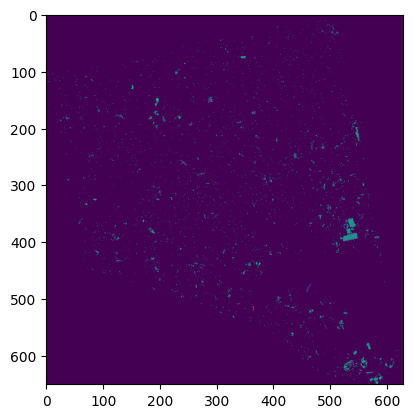

In [24]:
#reduce raster resolution with decimation to avoid kernel crashing
#visualize raster reading every 30th pixel

with ras.open(change1to2) as raster:
    decima = raster.read(1, out_shape=(1, int(raster.height / 30), int(raster.width / 30)))
    show(decima)
    raster.close()




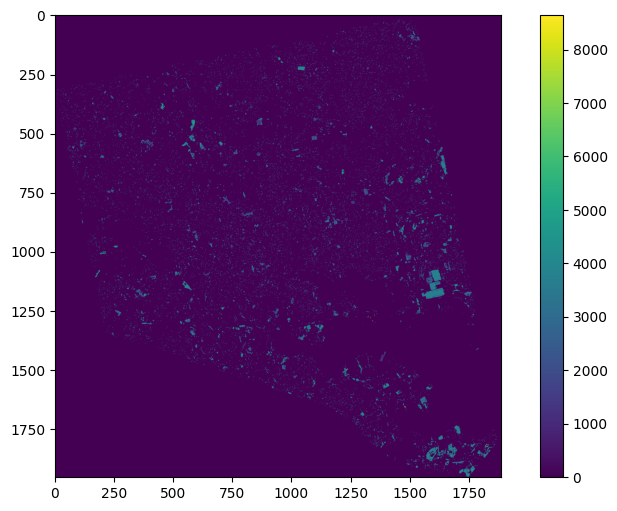

In [38]:
#reducing resolution to visualize raster without crashing
#uses 100x less pixels

from rasterio.enums import Resampling

with ras.open(change1to2) as rast:
    scale = 10
    data = rast.read(1,out_shape=(rast.height // scale,rast.width // scale),resampling=Resampling.average)
    
fig, ax = plt.subplots(figsize=(10, 6))
fig.colorbar(ax.imshow(data, cmap="viridis"), ax=ax)
plt.show()
rast.close()

